# Process AIT Log Data Set v2.0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## Load Data

In [2]:
# scenario = "santos"
# scenario = "fox"
scenario = "russellmitchell"

In [3]:
# Simulation and attack period can be found in the AIT-LDS V2 dataset documentation: https://doi.org/10.5281/zenodo.5789064

if scenario == "santos":
    sim_start = pd.Timestamp("2022-01-14 00:00")
    sim_end   = pd.Timestamp("2022-01-18 00:00")
    attack_start = pd.Timestamp("2022-01-17 11:15")
    attack_end   = pd.Timestamp("2022-01-17 11:59")

elif scenario == "fox":
    sim_start = pd.Timestamp("2022-01-15 00:00")
    sim_end   = pd.Timestamp("2022-01-20 00:00")
    attack_start = pd.Timestamp("2022-01-18 11:59")
    attack_end   = pd.Timestamp("2022-01-18 13:15")

elif scenario == "russellmitchell":
    sim_start = pd.Timestamp("2022-01-21 00:00")
    sim_end   = pd.Timestamp("2022-01-25 00:00")
    attack_start = pd.Timestamp("2022-01-24 03:01")
    attack_end   = pd.Timestamp("2022-01-24 04:39")

else:
    raise ValueError(f"Unknown scenario: {scenario}")

In [4]:
dataset = "aitv2"
data_dir = f"../../data/interim/{dataset}/{scenario}/flows_labeled"
df_all_sensors = pd.read_csv(f"{data_dir}/all_flows_labeled_unprocessed.csv")

## Trim to Simulation Period

In [5]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-20 12:48:19.071872950 to 2022-01-25 06:57:00.175499916
Total flows in combined dataset: 7828592


In [6]:
# Trim to simulation period
df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]
print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-21 00:00:00 to 2022-01-25 00:00:00
Total flows in simulation period: 6652956


## Remove Duplicate Rows

### Load Netflow Data

In [8]:
netflows_path = f"../../data/raw/{dataset}/{scenario}_netflows/all_netflows.csv"

df_netflows = pd.read_csv(netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
netflows_labels = df_netflows["label"].unique()

print(netflows_labels)
print(df_netflows_labels_counts)
print()

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'update/command on unassigned port'
 'DNS' 'monitoring' 'HTTP(S) intra' 'HTTP' 'HTTPS' 'host_discover_local'
 'dirb_scan' 'wpscan' 'upload_rce_shell' 'check_whoami' 'check_uname_r'
 'read_profile' 'check_who' 'check_meminfo' 'check_uname_a'
 'check_user_id' 'check_df' 'check_netstat_nat' 'check_id' 'read_resolv'
 'check_netstat_t' 'list_home' 'check_last' 'list_web_dir' 'check_date'
 'list_www' 'check_netstat_l' 'clear' 'check_wp_config' 'check_ps_a'
 'read_passwd' 'check_release' 'check_cpuinfo' 'dump_wp_users'
 'read_group' 'check_uptime' 'check_network_config'
 'dns_brute_force_start' 'HTTP(S) DMZ' 'broken flow - benign'
 'data exfiltration' 'mDNSv6' 'mDNS' 'NTP' 'bootp'
 'systemd-resolver (local)' 'benign DNS - attacker requesting updates'
 'benign DNS' 'OpenVPN' 'QUIC' 'GoogleDNS' 'NetBIOS']
label
host_discover_local     131068
benign DNS               69211
proxy          

### Check Labeling

In [9]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [10]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
missing_labels = [label for label in netflows_labels if label not in observed_labels]
print(missing_labels)

Unique labels observed across all sensors:
['read_resolv', 'list_www', 'list_home', 'check_uname_r', 'broken flow - benign', 'check_date', 'monitoring', 'list_web_dir', 'check_uname_a', 'HTTP(S) intra', 'QUIC', 'wpscan', 'NTP', 'benign', 'check_user_id', 'check_netstat_l', 'check_cpuinfo', 'service_scan', 'proxy', 'DNS', 'dirb_scan', 'HTTP', 'benign DNS', 'check_wp_config', 'read_group', 'upload_rce_shell', 'check_df', 'mail', 'check_last', 'update/command on unassigned port', 'check_release', 'dump_wp_users', 'SSH', 'benign DNS - attacker requesting updates', 'check_netstat_nat', 'benign_share', 'read_profile', 'check_id', 'check_network_config', 'online_cracking', 'HTTP(S) DMZ', 'HTTPS', 'check_netstat_t', 'check_meminfo', 'data exfiltration', 'dns_brute_force_start', 'check_whoami', 'clear', 'systemd-resolver (local)', 'host_discover_local', 'check_uptime', 'browsing/update', 'host_discover_dmz', 'check_who', 'check_ps_a', 'read_passwd', 'OpenVPN', 'bootp']
Labels in netflows but no

In [11]:
for label in observed_labels:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'read_resolv': 4
Number of flows with label 'read_resolv' in netflows: 2

Observed number of flows with label 'list_www': 4
Number of flows with label 'list_www' in netflows: 2

Observed number of flows with label 'list_home': 4
Number of flows with label 'list_home' in netflows: 2

Observed number of flows with label 'check_uname_r': 4
Number of flows with label 'check_uname_r' in netflows: 2

Observed number of flows with label 'broken flow - benign': 6170
Number of flows with label 'broken flow - benign' in netflows: 256

Observed number of flows with label 'check_date': 4
Number of flows with label 'check_date' in netflows: 2

Observed number of flows with label 'monitoring': 484
Number of flows with label 'monitoring' in netflows: 484

Observed number of flows with label 'list_web_dir': 4
Number of flows with label 'list_web_dir' in netflows: 2

Observed number of flows with label 'check_uname_a': 4
Number of flows with label 'check_uname_a' in 

In [12]:
label = "data exfiltration"
print("Data exfiltration label counts:")
print(f"Observed: {observed_labels_counts.get(label, 0)}")
print(f"Netflows: {df_netflows_labels_counts.get(label, 0)}")

Data exfiltration label counts:
Observed: 47322
Netflows: 15778


### Remove Duplicates

In [13]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_hash", "end_hash"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (6652956, 30)
Final dataset shape: (1263549, 27)


In [14]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'read_resolv': 2
Number of flows with label 'read_resolv' in netflows: 2

Observed number of flows with label 'list_www': 2
Number of flows with label 'list_www' in netflows: 2

Observed number of flows with label 'list_home': 2
Number of flows with label 'list_home' in netflows: 2

Observed number of flows with label 'check_uname_r': 2
Number of flows with label 'check_uname_r' in netflows: 2

Observed number of flows with label 'broken flow - benign': 430
Number of flows with label 'broken flow - benign' in netflows: 256

Observed number of flows with label 'check_date': 2
Number of flows with label 'check_date' in netflows: 2

Observed number of flows with label 'monitoring': 484
Number of flows with label 'monitoring' in netflows: 484

Observed number of flows with label 'list_web_dir': 2
Number of flows with label 'list_web_dir' in netflows: 2

Observed number of flows with label 'check_uname_a': 2
Number of flows with label 'check_uname_a' in n

### Save Final Dataset

In [15]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_flows_labeled_sim.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (1263549, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
1171545,f1974,1.642723e+09,1.642723e+09,0.025995,172.19.130.106,45414,10.143.0.103,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-21 00:00:02.274306059,2022-01-21 00:00:02.300301075
1171547,f3201,1.642723e+09,1.642723e+09,0.024022,172.19.130.106,45414,10.143.0.103,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-21 00:00:02.275362968,2022-01-21 00:00:02.299385071
1171549,f1975,1.642723e+09,1.642723e+09,0.015097,172.19.130.106,45416,10.143.0.103,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-21 00:00:02.345110893,2022-01-21 00:00:02.360207796
1171551,f3202,1.642723e+09,1.642723e+09,0.014199,172.19.130.106,45416,10.143.0.103,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-21 00:00:02.345201969,2022-01-21 00:00:02.359400988
1171553,f3203,1.642723e+09,1.642723e+09,0.017275,172.19.130.106,45418,10.143.0.103,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-21 00:00:02.410583019,2022-01-21 00:00:02.427858114


## Plotting

In [16]:
# From now on only use df
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [17]:
def plot_event_raster(df_attack, order, scenario_name, attack=False, invert_y=True, save_plot=False, file_path=None):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title(f"{scenario_name} MSA", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    if save_plot:
        plt.savefig(file_path, dpi=300, bbox_inches='tight')
    plt.show()

### Plot Full Simulation Period

In [18]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'update/command on unassigned port', 'DNS', 'monitoring', 'HTTP(S) intra', 'HTTP', 'HTTPS', 'host_discover_local', 'dirb_scan', 'wpscan', 'upload_rce_shell', 'check_whoami', 'check_uname_r', 'read_profile', 'check_who', 'check_meminfo', 'check_uname_a', 'check_user_id', 'check_df', 'check_netstat_nat', 'check_id', 'read_resolv', 'check_netstat_t', 'list_home', 'check_last', 'list_web_dir', 'check_date', 'list_www', 'check_netstat_l', 'clear', 'check_wp_config', 'check_ps_a', 'read_passwd', 'check_release', 'check_cpuinfo', 'dump_wp_users', 'read_group', 'check_uptime', 'check_network_config', 'dns_brute_force_start', 'HTTP(S) DMZ', 'broken flow - benign', 'data exfiltration', 'mDNSv6', 'mDNS', 'NTP', 'bootp', 'systemd-resolver (local)', 'benign DNS - attacker requesting updates', 'benign DNS', 'OpenVPN', 'QUIC', 'GoogleDNS', 'NetBIOS', 'ben

In [19]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
benign_share,2022-01-21 00:00:02.274306059,2022-01-24 23:45:01.846997976
benign,2022-01-21 00:00:04.183557034,2022-01-24 23:59:07.104701996
benign DNS,2022-01-21 00:00:09.628324032,2022-01-24 23:58:27.718372107
data exfiltration,2022-01-21 00:00:09.631012917,2022-01-24 04:38:08.210059881
browsing/update,2022-01-21 00:02:27.507829905,2022-01-24 23:55:15.094475985
NTP,2022-01-21 00:06:42.388700962,2022-01-24 23:59:57.389599085
monitoring,2022-01-21 00:09:06.756941080,2022-01-24 23:45:57.409503937
bootp,2022-01-21 04:59:22.883311033,2022-01-24 23:52:42.307125092
systemd-resolver (local),2022-01-21 05:24:26.317708015,2022-01-24 04:38:11.790888071


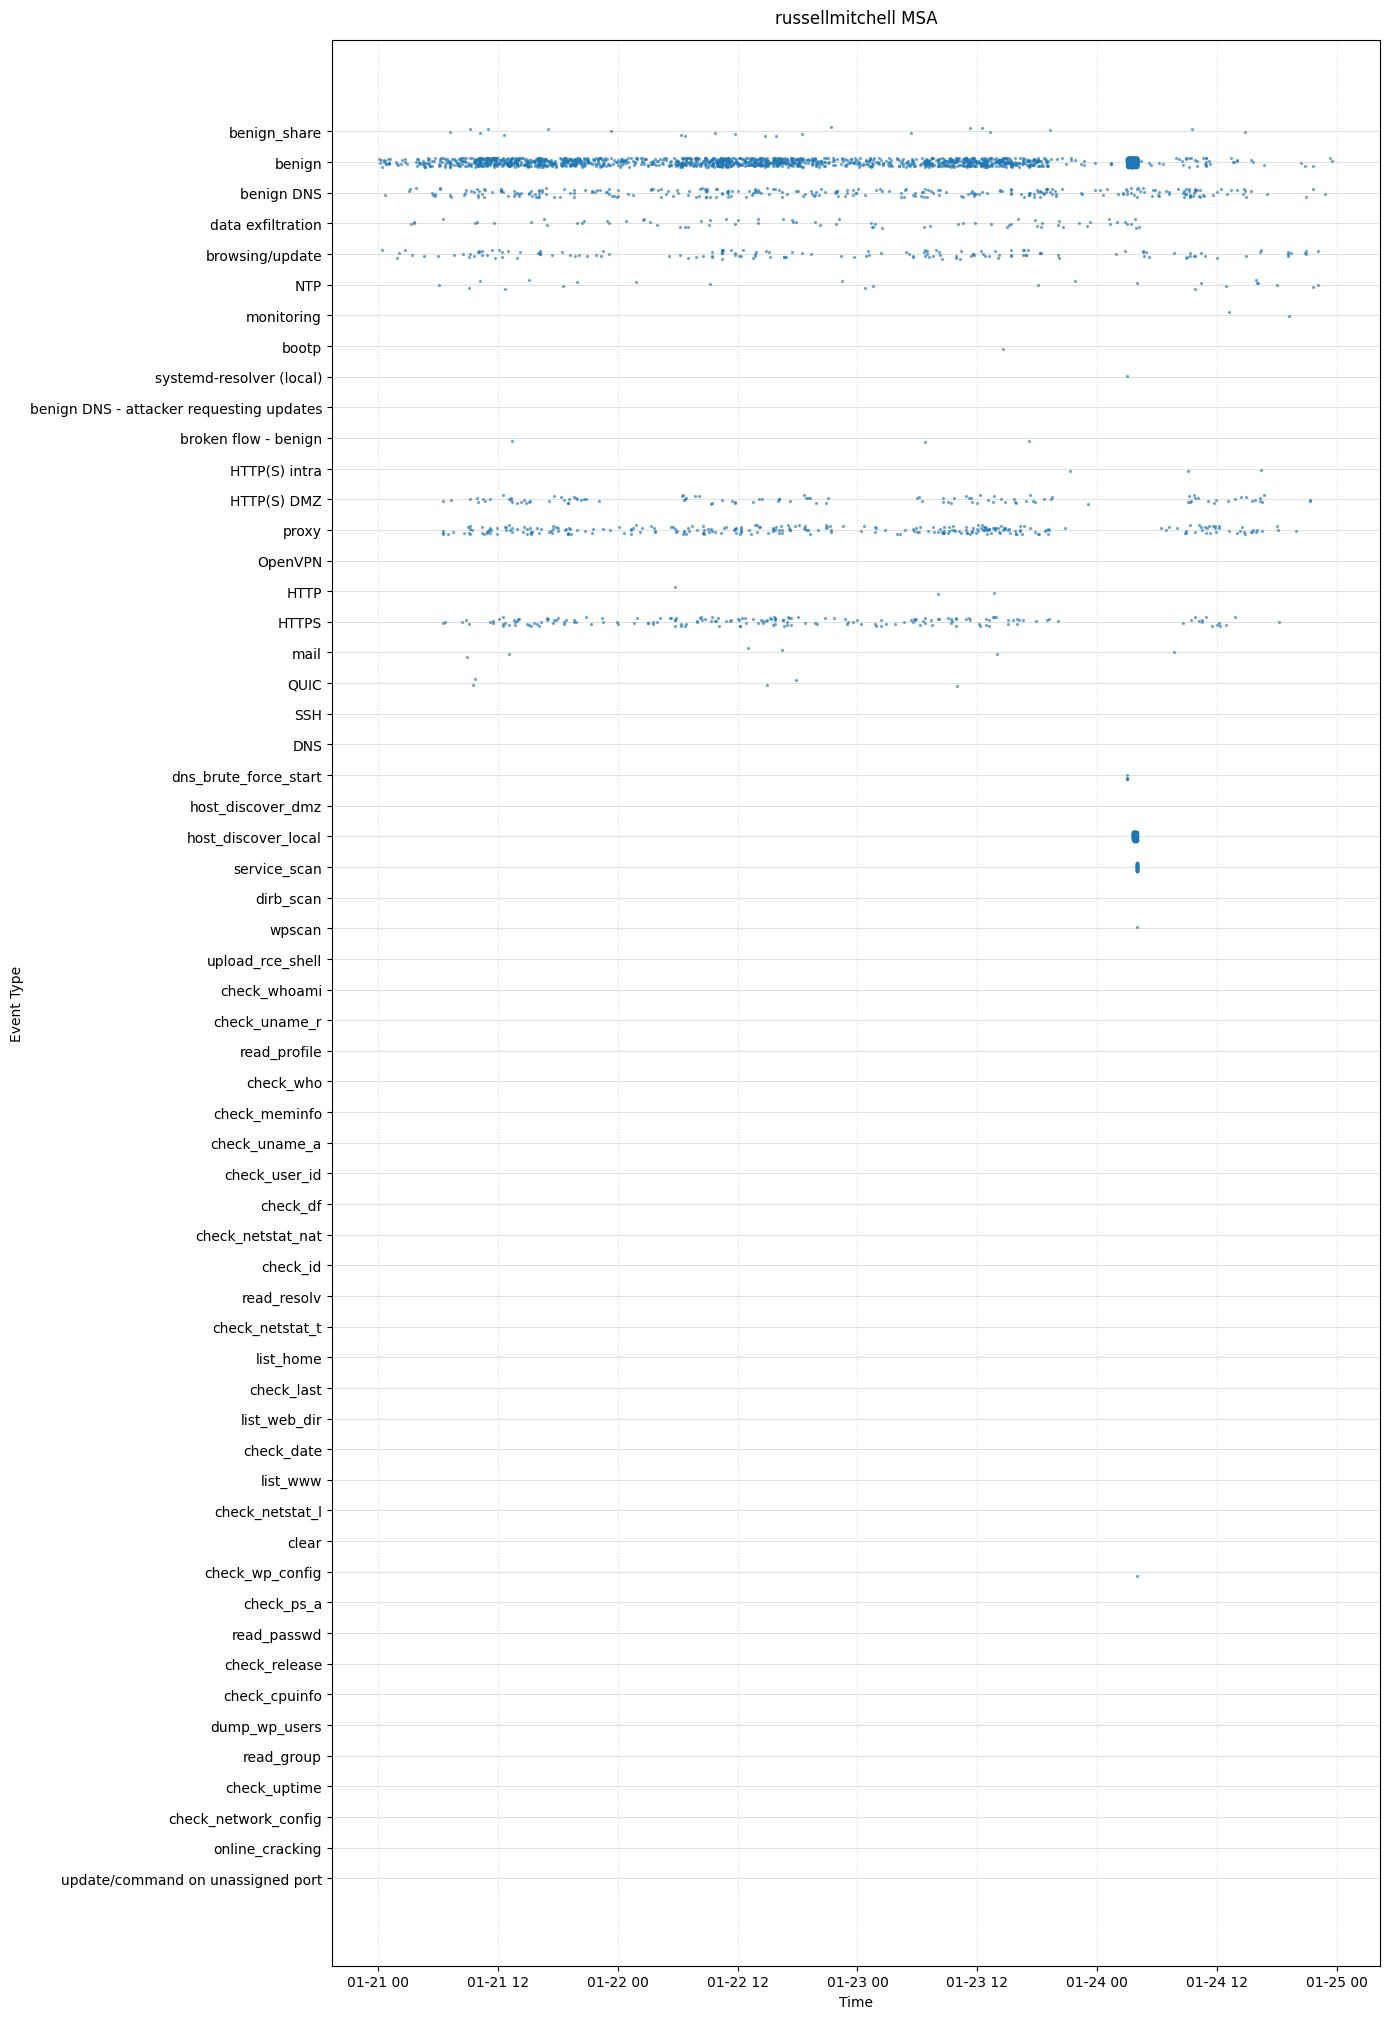

In [20]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df, order_sim, scenario)

### Plot Attack Period

In [21]:
print(f"Attack period - {scenario}:")
print(f"{attack_start} to {attack_end}")
    
df_attack_period = df[(df['start_time_dt'] >= attack_start) & (df['end_time_dt'] <= attack_end)]
print(f"Total attack flows in attack period: {len(df_attack_period)}")

Attack period - russellmitchell:
2022-01-24 03:01:00 to 2022-01-24 04:39:00
Total attack flows in attack period: 591941


In [22]:
phase_bounds_attack_period = (
    df_attack_period[df_attack_period['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack_period

,min,max
label,,
systemd-resolver (local),2022-01-24 03:01:00.087587118,2022-01-24 04:38:11.790888071
OpenVPN,2022-01-24 03:01:00.108052969,2022-01-24 03:01:00.108052969
benign,2022-01-24 03:01:00.112684965,2022-01-24 04:38:59.342051983
NTP,2022-01-24 03:01:01.283462048,2022-01-24 04:38:11.857721090
benign DNS,2022-01-24 03:01:15.415937901,2022-01-24 04:38:59.338845968
data exfiltration,2022-01-24 03:01:15.419787884,2022-01-24 04:38:08.210059881
dns_brute_force_start,2022-01-24 03:01:21.480389118,2022-01-24 03:01:21.567158937
host_discover_dmz,2022-01-24 03:01:29.486834049,2022-01-24 03:01:41.666013956
browsing/update,2022-01-24 03:02:54.905231953,2022-01-24 04:34:15.527959108


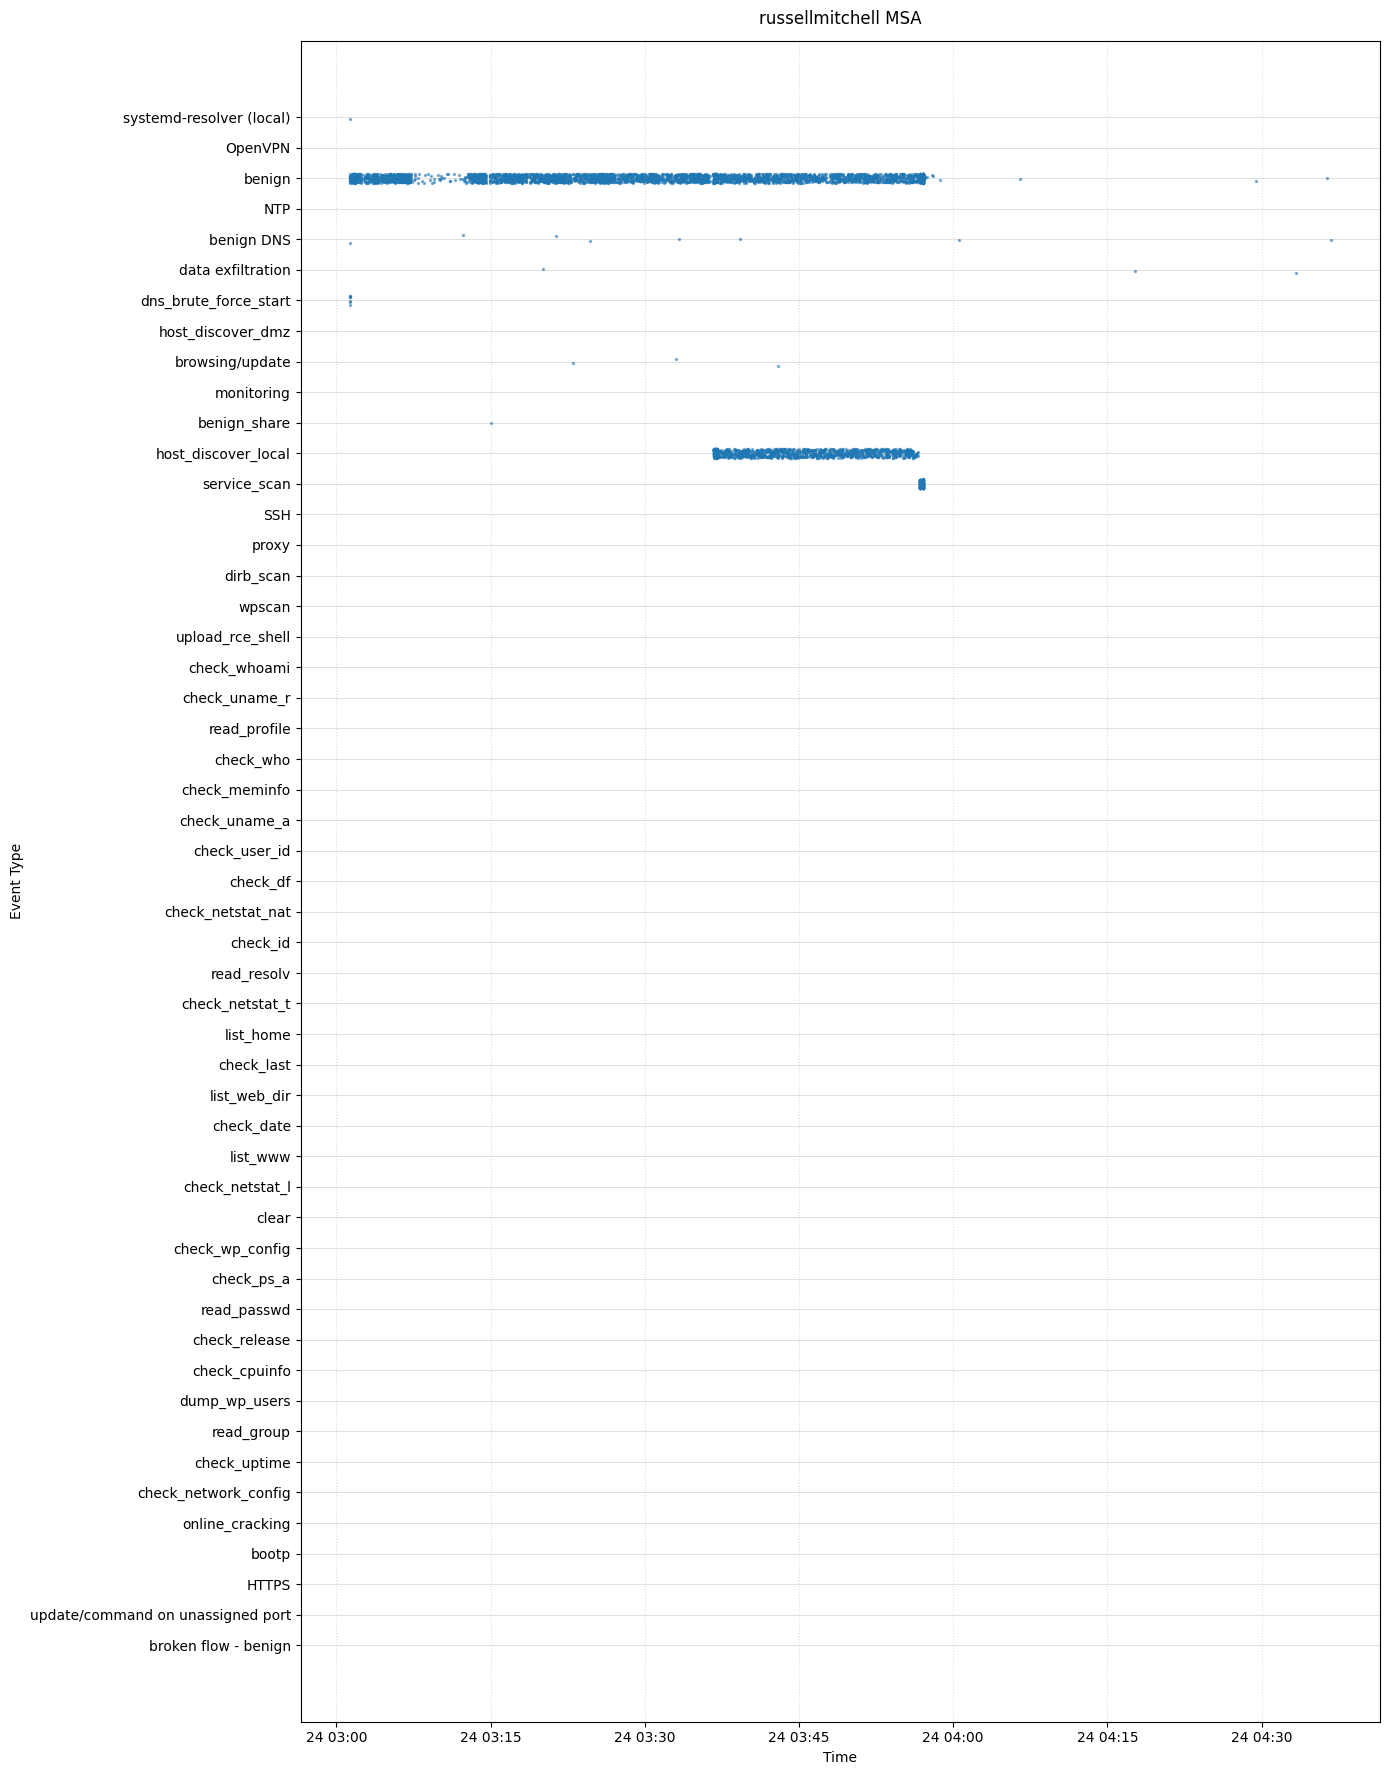

In [23]:
order_attack_period = phase_bounds_attack_period.index.tolist()
plot_event_raster(df_attack_period, order_attack_period, scenario)

### Label Multi-Step Attack

**Multi-Step Attack Phases**

Scans / reconnaissance:
- The first step of the attack chain then consists of several scans of the network.

Webshell upload / exploitation:
- Attacker exploits the vulnerable plugin which allows him to upload a PHP webshell as a backdoor.
- The attacker proceeds to execute several commands to gather information about the host.

Password cracking: 
- The attacker then attempts to crack one of the hashed passwords using a list of common passwords.

Privilege escalation: 
- Subsequently after obtaining the password, the attacker uploads a fully interactive reverse shell and misuses the compromised user account to escalate their privileges to root level. 

Remote command execution: 
- The attacker then executes several commands of which some require root privileges, such as reading out the shadow file.

Data exfiltration:
- As a final step of the attack kill chain, the attacker runs the DNSteal tool that exfiltrates sensitive data from the file share located in the intranet zone.
- Important note: The authors decided to separate this step from the remaining attack vectors and instead start the exfiltration tool already at the beginning of the simulation.

Missing steps in Zeek flow data:
- Privilege escalation and remote command execution are not present in the Zeek flow data, which is likely due to the fact that these steps do not involve any network communication.

In [75]:
# From netflows labeling file:
benign_tcp_complete_labels = ["browsing/update", "benign_share", "mail", "monitoring", "HTTP(S) intra", "HTTP(S) DMZ", "SSH", "proxy", "HTTPS", "HTTP", "DNS", "update/command on unassigned port"]
benign_tcp_nocomplete_labels = ["broken flow - benign"]
benign_udp_labels = ["NTP", "bootp", "OpenVPN", "STUN VoIP", "NetBIOS", "QUIC", "mDNS", "mDNSv6", "GoogleDNS", "systemd-resolver (local)", "benign DNS", "benign DNS - attacker requesting updates"]

benign_labels = benign_tcp_complete_labels + benign_tcp_nocomplete_labels + benign_udp_labels + ["benign"]

In [98]:
exact_exploit_labels = ['upload_rce_shell', 'clear']
exploit_prefixes = (
    "check",
    "list",
    "read",
    "dump",
)

exploit_labels = sorted(
    label
    for label in observed_labels
    if label in exact_exploit_labels or label.startswith(exploit_prefixes)
)

In [99]:
exfil_labels = ['data exfiltration']
recon_labels = ['dns_brute_force_start', 'host_discover_local', 'host_discover_dmz', 'service_scan', 'wpscan', 'dirb_scan']
cracking_labels = ['online_cracking']

explicit_attack_labels = recon_labels + exploit_labels + cracking_labels + exfil_labels

In [ ]:
observed_labels = set(df_sim["label"].unique())

msa_labels = sorted(
    label
    for label in observed_labels
    if label in explicit_attack_labels
)

In [101]:
unknown_labels = (
    observed_labels
    - set(benign_labels)
    - set(msa_labels)
)

if unknown_labels:
    print("Labels not categorized:")
    for label in sorted(unknown_labels):
        print(label)

In [102]:
df_msa = df_attack_period[df_attack_period["label"].isin(msa_labels)]
print(f"Total multi-step attack flows in true attack period: {len(df_msa)}")

Total multi-step attack flows in true attack period: 155678


In [103]:
obs_msa_labels, obs_msa_label_counts = \
    get_observed_labels_and_counts(df_msa)

for label in obs_msa_labels:
    print(f"Observed number of flows with msa label '{label}': {obs_msa_label_counts[label]}")
    print(f"Number of flows with msa label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with msa label 'read_resolv': 2
Number of flows with msa label 'read_resolv' in netflows: 2

Observed number of flows with msa label 'list_www': 2
Number of flows with msa label 'list_www' in netflows: 2

Observed number of flows with msa label 'list_home': 2
Number of flows with msa label 'list_home' in netflows: 2

Observed number of flows with msa label 'check_uname_r': 2
Number of flows with msa label 'check_uname_r' in netflows: 2

Observed number of flows with msa label 'check_date': 2
Number of flows with msa label 'check_date' in netflows: 2

Observed number of flows with msa label 'list_web_dir': 2
Number of flows with msa label 'list_web_dir' in netflows: 2

Observed number of flows with msa label 'wpscan': 76
Number of flows with msa label 'wpscan' in netflows: 76

Observed number of flows with msa label 'check_netstat_l': 2
Number of flows with msa label 'check_netstat_l' in netflows: 2

Observed number of flows with msa label 'check_user_id': 2
Num

In [104]:
phase_bounds_msa = (
    df_msa
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_msa

,min,max
label,,
data exfiltration,2022-01-24 03:01:15.419787884,2022-01-24 04:38:08.210059881
dns_brute_force_start,2022-01-24 03:01:21.480389118,2022-01-24 03:01:21.567158937
host_discover_dmz,2022-01-24 03:01:29.486834049,2022-01-24 03:01:41.666013956
host_discover_local,2022-01-24 03:36:39.004187107,2022-01-24 03:56:34.905323029
service_scan,2022-01-24 03:56:47.146476030,2022-01-24 03:57:18.741014957
dirb_scan,2022-01-24 03:57:26.633027077,2022-01-24 03:57:39.522106886
wpscan,2022-01-24 03:57:52.307566881,2022-01-24 03:58:10.053653955
upload_rce_shell,2022-01-24 03:58:20.041800976,2022-01-24 03:58:20.042423964
check_whoami,2022-01-24 03:58:23.354427099,2022-01-24 03:58:23.354770899


In [105]:
out_dir = Path(f"../../reports/{dataset}/msa_scenarios")
out_dir.mkdir(parents=True, exist_ok=True)
file_path = out_dir / f"{scenario}.png"

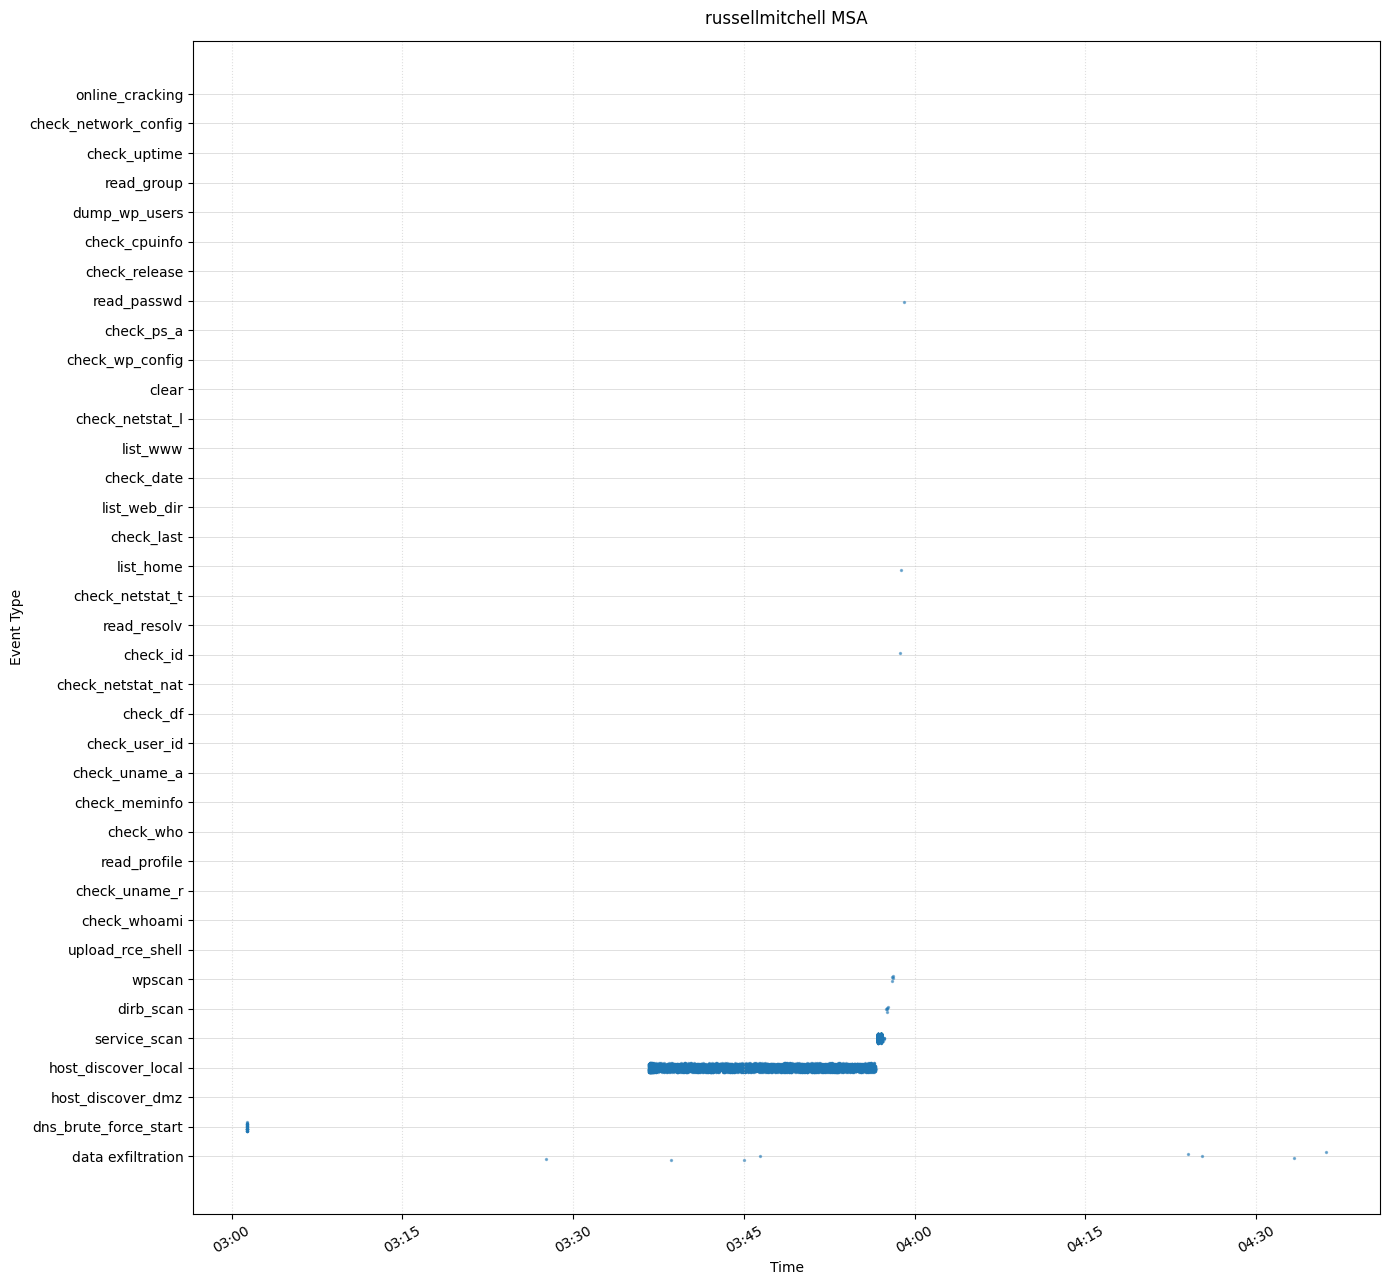

In [106]:
order_msa = phase_bounds_msa.index.tolist()
plot_event_raster(df_attack=df_msa, order=order_msa, scenario_name=scenario, attack=True, invert_y=False, save_plot=True, file_path = file_path)

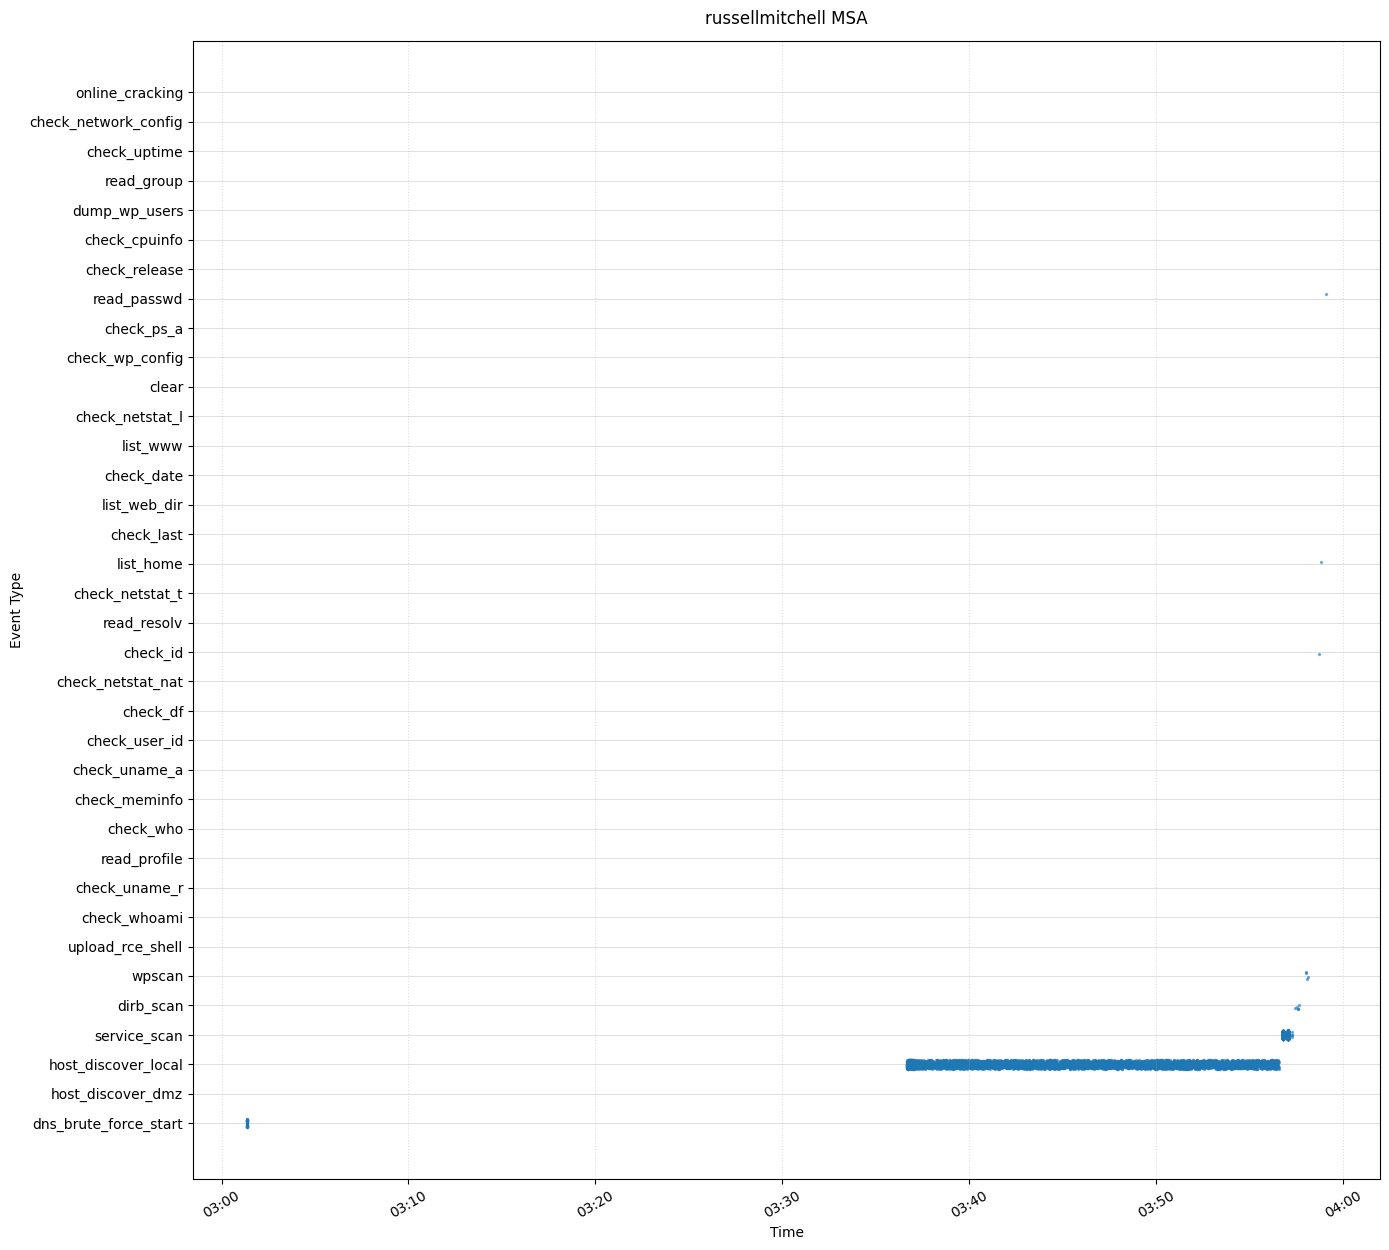

In [107]:
phase_bounds_msa_no_exfil = (
    df_msa[df_msa['label'] != 'data exfiltration']
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

order_msa_no_exfil = phase_bounds_msa_no_exfil.index.tolist()
plot_event_raster(df_attack=df_msa, order=order_msa_no_exfil, scenario_name=scenario, attack=True, invert_y=False)

In [118]:
def label_phase(label):
    if label in exfil_labels:
        return 1
    if label in recon_labels:
        return 2
    elif label in exploit_labels:
        return 3
    elif label in cracking_labels:
        return 4
    else: # benign or unknown
        return 0
    
# Reload the dataset to ensure we have the original labels before adding the phase column
df = pd.read_csv(f"{data_dir}/all_flows_labeled_sim.csv")

df["phase"] = df["label"].apply(label_phase)
label_counts = df["phase"].value_counts()
print("Phase distribution:")
print(label_counts)
df.to_csv(f"{data_dir}/all_flows_labeled.csv", index=False)

Phase distribution:
phase
0    1092413
2     155276
1      15789
3         58
4         13
Name: count, dtype: int64


## Dataset Statistics

In [119]:
def label_stats(df, field, sensor_host, plot_bar=True):
    label_counts = (
        df[field]
        .value_counts()
        .sort_index()
    )

    print(f"Label Distribution for {sensor_host}:")
    print(label_counts)

    if plot_bar:
        fig, ax = plt.subplots(figsize=(8, 5))

        bars = ax.bar(
            label_counts.index.astype(str),
            label_counts.values
        )

        # Log scale for imbalance visibility
        ax.set_yscale("log")

        # Titles and labels
        ax.set_title(
            f"Label Distribution: {sensor_host}",
            fontsize=14,
            pad=15
        )
        ax.set_xlabel("Phase", fontsize=12)
        ax.set_ylabel("Count (log scale)", fontsize=12)

        # Grid for readability
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        # Add value labels on top of bars
        for bar, value in zip(bars, label_counts.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:,}",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=0
            )

        # Cleaner layout
        plt.tight_layout()
        plt.show()

    print()

Label Distribution for russellmitchell:
phase
0    1092413
1      15789
2     155276
3         58
4         13
Name: count, dtype: int64


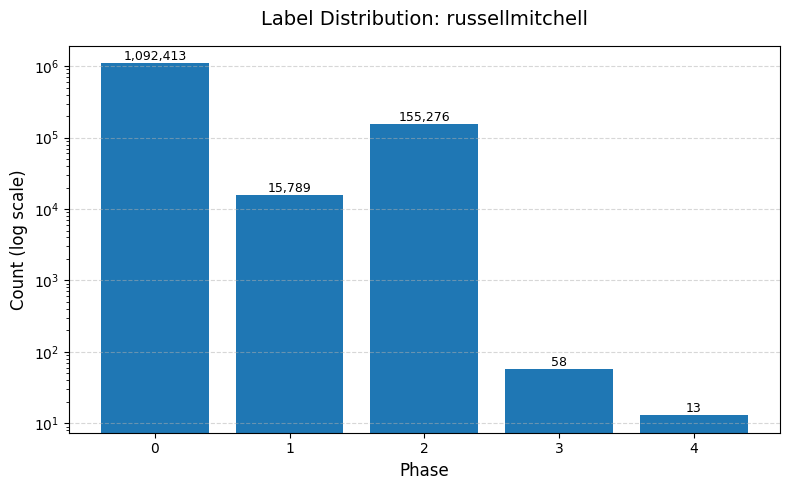

In [120]:
label_stats(df, "phase", scenario)

In [121]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [122]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

In [123]:
def label_stats(df, field, sensor_host, plot_bar=True):
    label_counts = df[field].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

Label Distribution for All Sensors:
label
host_discover_local      131068
service_scan              23207
dns_brute_force_start       814
data exfiltration           331
dirb_scan                    90
wpscan                       76
host_discover_dmz            21
online_cracking              13
upload_rce_shell              2
check_uname_r                 2
read_profile                  2
check_who                     2
check_whoami                  2
check_uname_a                 2
check_user_id                 2
check_df                      2
check_netstat_nat             2
check_id                      2
read_resolv                   2
check_netstat_t               2
check_meminfo                 2
list_home                     2
check_last                    2
check_date                    2
list_web_dir                  2
check_netstat_l               2
clear                         2
check_wp_config               2
list_www                      2
check_ps_a                    

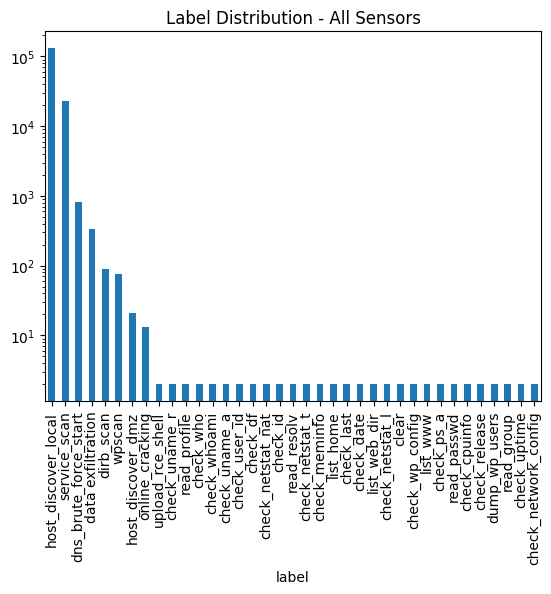

In [124]:
label_stats(df_msa, "label", "All Sensors")

In [125]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 1263549
Unique Source IPs: 100
Unique Destination IPs: 67631
Unique Source Ports: 49981
Unique Destination Ports: 11912


{'total_flows': 1263549,
 'unique_src_ips': 100,
 'unique_dst_ips': 67631,
 'unique_src_ports': 49981,
 'unique_dst_ports': 11912}

In [126]:
# Attack flows stats
dataset_stats(df_msa)

Total Flows: 155678
Unique Source IPs: 5
Unique Destination IPs: 32779
Unique Source Ports: 14375
Unique Destination Ports: 1761


{'total_flows': 155678,
 'unique_src_ips': 5,
 'unique_dst_ips': 32779,
 'unique_src_ports': 14375,
 'unique_dst_ports': 1761}

In [127]:
dataset_stats_detailed(df_msa)

Total Flows: 155678

 --- IP distribution ---

Source IPs (5):
src_ip
172.19.131.174     146311
192.168.230.122      9031
192.168.231.254       331
192.168.230.4           4
10.143.2.4              1
Name: count, dtype: int64

Destination IPs (32779):
dst_ip
10.143.2.4       3786
192.168.230.4    3594
172.19.130.4     2746
172.19.130.68    2711
10.143.0.103     2668
                 ... 
10.143.2.25         2
10.143.0.35         2
172.19.128.2        2
10.143.3.65         1
10.143.0.1          1
Name: count, Length: 32779, dtype: int64

 --- Port distribution ---
Source Ports (14375):
sport
34134    31
36576    30
51602    28
45790    26
47716    25
         ..
63176     1
51111     1
19048     1
5337      1
41483     1
Name: count, Length: 14375, dtype: int64

Destination Ports (1761):
dport
443     65900
80      65705
53        350
587       101
993        37
        ...  
1911       11
1101       11
918        11
2882       11
1336       11
Name: count, Length: 1761, dtype: int64


(src_ip
 172.19.131.174     146311
 192.168.230.122      9031
 192.168.231.254       331
 192.168.230.4           4
 10.143.2.4              1
 Name: count, dtype: int64,
 dst_ip
 10.143.2.4       3786
 192.168.230.4    3594
 172.19.130.4     2746
 172.19.130.68    2711
 10.143.0.103     2668
                  ... 
 10.143.2.25         2
 10.143.0.35         2
 172.19.128.2        2
 10.143.3.65         1
 10.143.0.1          1
 Name: count, Length: 32779, dtype: int64,
 sport
 34134    31
 36576    30
 51602    28
 45790    26
 47716    25
          ..
 63176     1
 51111     1
 19048     1
 5337      1
 41483     1
 Name: count, Length: 14375, dtype: int64,
 dport
 443     65900
 80      65705
 53        350
 587       101
 993        37
         ...  
 1911       11
 1101       11
 918        11
 2882       11
 1336       11
 Name: count, Length: 1761, dtype: int64)